veuillez télécharger le dataset qui est un fichier .csv disponible à l'adresse suivante :
<https://github.com/webdevproformation/m2-iot-juin2026/blob/main/jour03/08-titanic.csv>

In [ ]:
import pandas as pd

data = pd.read_csv("08-titanic.csv")
#      pd.read_json()
#      pd.read_excel()
#      pd.read_sql()

data.head(2) # afficher les premières lignes de ton fichier csv


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C


In [12]:
data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [ ]:
data.shape
# 1309 lignes => passagers
# 12 colonnes => caractéristiques 
#   - survived = 0 1
#   - sex  => homme femme
#   - age  => 
#   - Pclass => 1er classe 2eme classe et 3 eme classe

(1309, 12)

In [ ]:
data.describe() # donner des infos de bases sur tes données 
# la colonne age a des cellules vides 1046.000000

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,1309.000000,1309.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000
mean,655.000000,0.377387,2.294882,29.881138,0.498854,0.385027,33.295479
std,378.020061,0.484918,0.837836,14.413493,1.041658,0.865560,51.758668
min,1.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,328.000000,0.000000,2.000000,21.000000,0.000000,0.000000,7.895800
50%,655.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,982.000000,1.000000,3.000000,39.000000,1.000000,0.000000,31.275000
max,1309.000000,1.000000,3.000000,80.000000,8.000000,9.000000,512.329200


nettoyage => supprimer les colonnes dont on n'a pas besoin ET enlever les lignes dans lesquelles il y a des cellules vides

supprimer des colonnes

In [20]:
data = pd.read_csv("08-titanic.csv")
data = data.drop(
        ['PassengerId', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
        axis=1)
data.head()

,Survived,Pclass,Name,Sex,Age
0,0,3,"Braund, Mr. Owen Harris",male,22.0
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0
2,1,3,"Heikkinen, Miss. Laina",female,26.0
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0
4,0,3,"Allen, Mr. William Henry",male,35.0


supprimer toutes les lignes où l'âge est non noté

In [23]:
data = data.dropna(axis=0)
data.describe()
data.shape

(1046, 5)

autre possibilité : si tu ne veux pas supprimer les lignes 
data.fillna()

des fonctions intéressantes pour la machine learning
value_counts()

In [24]:
# combien on survécu / pas survecu
data["Survived"].value_counts()


Survived
0    629
1    417
Name: count, dtype: int64

In [25]:
data["Pclass"].value_counts()

Pclass
3    501
1    284
2    261
Name: count, dtype: int64

<Axes: xlabel='Pclass'>

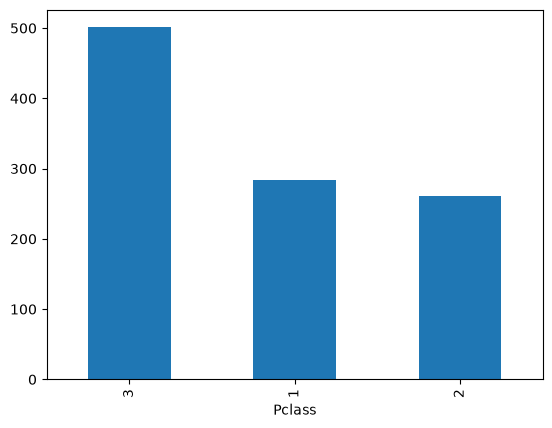

In [26]:
data["Pclass"].value_counts().plot.bar()

<Axes: >

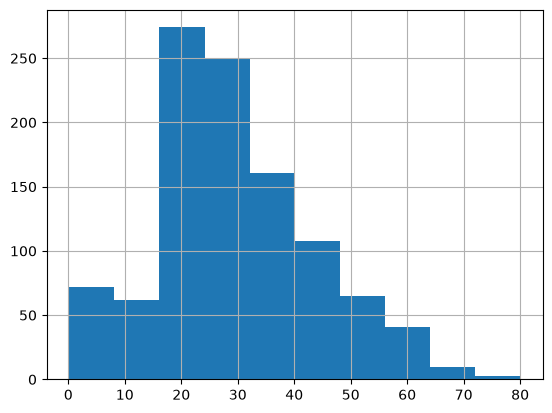

In [32]:
data["Age"].hist() # voici 

In [ ]:
# tableau croisé dynamique

In [46]:
data.groupby('Pclass')['Age'].mean()

Pclass
1    39.159930
2    29.506705
3    24.816367
Name: Age, dtype: float64

NumPy => ND Array = Tableau à N Dimensions

data = pd.read_csv("08-titanic.csv")

DataFrames : vos données qui ont été téléchargée dans la librairie ET une colonne automatiquement ajoutée index numérique 

il est possible de changer les chiffres qui son écrit par défaut par une autre valeur 
une colonne de vos données => Nom de la personne ou plus intéressant 


In [47]:
data["Age"]

0       22.0
1       38.0
2       26.0
3       35.0
4       35.0
        ... 
1300     3.0
1302    37.0
1303    28.0
1305    39.0
1306    38.5
Name: Age, Length: 1046, dtype: float64

opérations que l'on peut réaliser sur des Dataframes
changer la valeur numérique de l'index par la colonne nom de nos données

In [ ]:
data = pd.read_csv("08-titanic.csv")
data = data.drop(
        ['PassengerId', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
        axis=1)
data = data.dropna(axis=0)
data = data.set_index("Name")


Name
Braund, Mr. Owen Harris                                22.0
Cumings, Mrs. John Bradley (Florence Briggs Thayer)    38.0
Heikkinen, Miss. Laina                                 26.0
Futrelle, Mrs. Jacques Heath (Lily May Peel)           35.0
Allen, Mr. William Henry                               35.0
                                                       ... 
Peacock, Miss. Treasteall                               3.0
Minahan, Mrs. William Edward (Lillian E Thorpe)        37.0
Henriksson, Miss. Jenny Lovisa                         28.0
Oliva y Ocana, Dona. Fermina                           39.0
Saether, Mr. Simon Sivertsen                           38.5
Name: Age, Length: 1046, dtype: float64

In [ ]:
data["Age"][0:3] # slicing comme pour numpy

Name
Braund, Mr. Owen Harris                                22.0
Cumings, Mrs. John Bradley (Florence Briggs Thayer)    38.0
Heikkinen, Miss. Laina                                 26.0
Name: Age, dtype: float64

je veux étudier UNIQUEMENT les passager mineurs qui ont moins de 18 ans

In [ ]:
print(data.describe())
masque = data["Age"] < 18
print(masque)

data[masque].describe() # enlever toutes les lignes où l'age du passager est >= 18
# sur les 1046 passager il reste 154 passagers mineurs

          Survived       Pclass          Age
count  1046.000000  1046.000000  1046.000000
mean      0.398662     2.207457    29.881138
std       0.489857     0.841497    14.413493
min       0.000000     1.000000     0.170000
25%       0.000000     1.000000    21.000000
50%       0.000000     2.000000    28.000000
75%       1.000000     3.000000    39.000000
max       1.000000     3.000000    80.000000
Name
Braund, Mr. Owen Harris                                False
Cumings, Mrs. John Bradley (Florence Briggs Thayer)    False
Heikkinen, Miss. Laina                                 False
Futrelle, Mrs. Jacques Heath (Lily May Peel)           False
Allen, Mr. William Henry                               False
                                                       ...  
Peacock, Miss. Treasteall                               True
Minahan, Mrs. William Edward (Lillian E Thorpe)        False
Henriksson, Miss. Jenny Lovisa                         False
Oliva y Ocana, Dona. Fermina             

,Survived,Pclass,Age
count,154.000000,154.000000,154.000000
mean,0.506494,2.590909,9.101753
std,0.501589,0.662868,6.015397
min,0.000000,1.000000,0.170000
25%,0.000000,2.000000,3.000000
50%,1.000000,3.000000,9.000000
75%,1.000000,3.000000,15.750000
max,1.000000,3.000000,17.000000


In [ ]:
# il est possible d'effectuer toutes les opérations que l'on a saisie en 1 seule ligne puissante
# pour tous les passagers de moins de 18 ans, moyenne de l'age regroupé par classe

data[data["Age"] < 18].groupby("Pclass")['Age'].mean()

Pclass
1    12.128000
2     7.340909
3     9.221698
Name: Age, dtype: float64

loc et iloc
par défaut lorsque l'on veut accéder à une colonne dans le dataframe on doit utiliser le nom de la colonne

In [61]:
data.head(1)

,Survived,Pclass,Sex,Age
Name,,,,
"Braund, Mr. Owen Harris",0,3,male,22.0


In [64]:
data["Pclass"][0:1]

Name
Braund, Mr. Owen Harris    3
Name: Pclass, dtype: int64

In [ ]:
data.iloc[0:1, 1:2] # accéder aux valeurs via leur position (comme le slicing avec numpy)

,Pclass
Name,
"Braund, Mr. Owen Harris",3
